Project Title: Denoising MNIST Digits Using Variational Autoencoders

# Project Objective:

The objective of this project is to develop a Variational Autoencoder (VAE) model capable of performing image denoising on the MNIST handwritten digits dataset. By training the VAE to reconstruct clean images from noisy inputs, the model learns a compressed latent representation that captures the essential features of the data while ignoring noise. This project demonstrates the effectiveness of generative models like VAE for practical denoising tasks, with potential applications in image restoration, preprocessing, and anomaly detection.

Google Colab is a cloud-based Jupyter notebook environment provided by Google for free. It allows users to write and execute Python code in a collaborative and interactive manner, directly from their web browser. With Colab, users can easily share their notebooks, access powerful computing resources, and leverage pre-installed libraries for data analysis, machine learning, and more.

Mounting Google Drive in Google Colab allows you to access and interact with files stored in your Google Drive directly from your Colab notebook. This is useful for accessing datasets, saving trained models, or working with any other files stored in your Google Drive. It provides a convenient way to leverage the storage and collaboration capabilities of Google Drive within the Colab environment

In [ ]:
from google.colab import drive
drive.mount("gdrive")

Mounted at gdrive


Note:
Google Colab provides access to GPUs (Graphical Processing Units) to accelerate computations, particularly for deep learning tasks. This accelerates model training and inference, making it faster compared to using only CPU resources. To enable GPU support in Colab, you can select the "GPU" option from the "Runtime" menu and then choose "Change runtime type." This will allocate a GPU for your notebook session, allowing you to train deep learning models more efficiently. The choice of epochs value depends on various factors such as dataset size, model complexity, and training convergence, and it should be selected based on experimentation and monitoring of training performance.

The below set of library initialization for implementing VAE

 The os module provides tools to interact with the operating system, such as file path handling. torch is the main PyTorch library used for building and training deep learning models. torch.nn contains essential neural network building blocks like layers and loss functions. Finally, torch.nn.functional offers stateless functions like activations (e.g., ReLU, softmax) and convolution operations used in defining model behavior.

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

These are hyperparameters used to train a Variational Autoencoder (VAE) model. num_epochs = 50 means the model will train over the dataset 50 times. use_gpu = True enables GPU acceleration if available, improving training speed. batch_size = 16 sets the number of samples processed before the model updates its weights. learning_rate = 0.0001 controls how much the model adjusts its weights at each step; a smaller value leads to more stable learning. latent_dims = 2 defines the size of the latent (compressed) space, and variational_beta = 1 sets the strength of the KL-divergence term, balancing reconstruction and regularization. capacity = 64 defines the number of feature maps or neurons in intermediate layers, controlling model complexity.

In [ ]:
num_epochs = 50
use_gpu = True
batch_size = 16
learning_rate = 0.0001
latent_dims = 2
variational_beta = 1
capacity = 64

Information About MNIST:

The MNIST (Modified National Institute of Standards and Technology) dataset is a benchmark dataset widely used for training and evaluating image processing systems, especially in machine learning and deep learning.

Here are key details about the MNIST dataset:

Content: It consists of 70,000 grayscale images of handwritten digits from 0 to 9.

60,000 images are used for training.

10,000 images are used for testing.

Image Size: Each image is 28x28 pixels, stored in a 2D format with 1 color channel (grayscale).

Label Format: Each image is paired with a label representing the digit it depicts (integer 0–9).

Use Cases: It's commonly used in:

Digit classification

Image generation

Variational Autoencoders (VAEs)

GANs

Computer vision education

Advantages:

Clean and preprocessed.

Small size allows for quick experiments.

Well-balanced classes and widely benchmarked results.

In [ ]:
# For image preprocessing like normalization, tensor conversion, etc.
import torchvision.transforms as transforms

# For loading data in batches and shuffling
from torch.utils.data import DataLoader

# PyTorch utility to load the MNIST handwritten digits dataset
from torchvision.datasets import MNIST

# Converts images to PyTorch tensors and normalizes pixel values to [0, 1]
img_transform = transforms.Compose([
    transforms.ToTensor()
])

# Loads the training set of MNIST with transformation applied
train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)

# Creates a data loader for training data with shuffling and batch loading
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Loads the test set of MNIST with the same transformation
test_dataset = MNIST(root='./data/MNIST', download=True, train=False, transform=img_transform)

# Creates a data loader for test data with shuffling and batch loading
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.75MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.50MB/s]


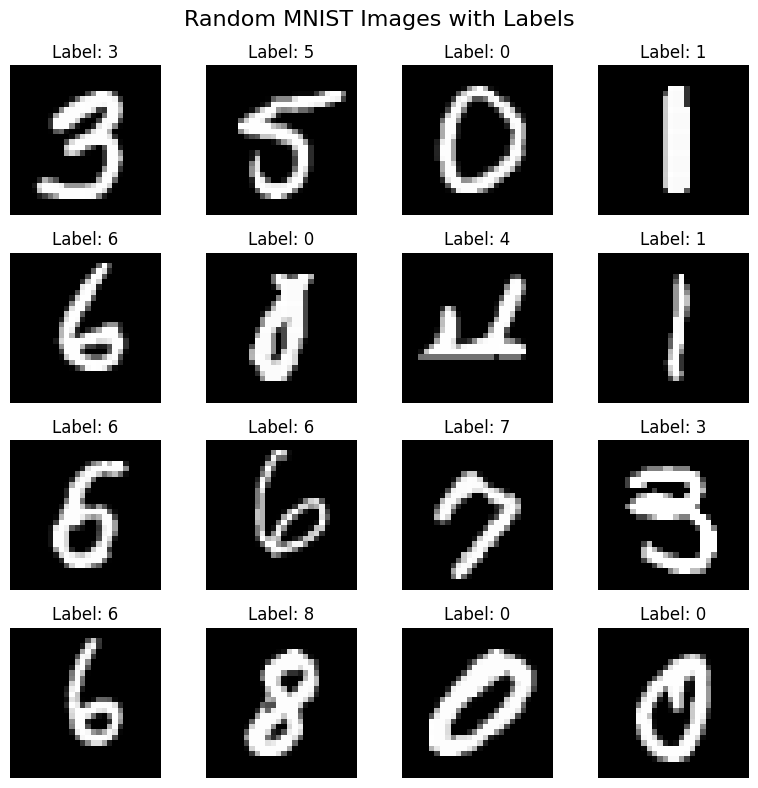

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Get one batch of data
images, labels = next(iter(train_dataloader))

# Determine how many images to show (min of 25 or batch size)
num_images = min(25, len(images))

# Set up grid size (e.g. 5x5 or smaller)
grid_size = int(np.ceil(np.sqrt(num_images)))

fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
fig.suptitle("Random MNIST Images with Labels", fontsize=16)

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < num_images:
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')  # Hide axis for all plots

plt.tight_layout()
plt.show()


transforms: Part of torchvision, used to define preprocessing operations for images, such as converting to tensor, resizing, normalizing, etc.

DataLoader: A PyTorch utility that allows you to iterate over a dataset in batches, with options for shuffling and parallel loading.

MNIST: A built-in dataset loader provided by torchvision.datasets for the MNIST handwritten digit dataset.

transforms.Compose: Chains together multiple preprocessing transformations.

transforms.ToTensor(): Converts PIL images or NumPy arrays to PyTorch tensors and scales pixel values from [0, 255] to [0.0, 1.0].

Loads the training split of the MNIST dataset.

root='./data/MNIST': Specifies the directory where the data will be saved.

download=True: Automatically downloads the dataset if it's not already present.

train=True: Indicates we want the training portion of the dataset.

transform=img_transform: Applies the ToTensor() transform to each image.

Wraps the training dataset in a DataLoader for batching and shuffling.

batch_size=batch_size: Defines how many images are included in each batch (e.g., 16 if previously set).

shuffle=True: Shuffles the dataset before each epoch to ensure model generalization.

Similar to the training dataset, but:

train=False loads the test set of the MNIST dataset.

Creates a DataLoader for the test dataset with the same batch size and shuffling enabled.

# VAE:Variational Auto Encoder:

1.Variational Autoencoders (VAEs) are a type of generative model that learn to encode data into a latent space and then decode it back to the original input space.

2.Unlike traditional autoencoders, VAEs learn distributions over the latent space instead of deterministic encodings.

3.They model the encoder output as a mean and variance, forming a Gaussian distribution for each input.

4.A key idea in VAEs is sampling from this distribution during training using the reparameterization trick to allow backpropagation.

5.The loss function in VAE includes a reconstruction loss (e.g., MSE) and a KL divergence term to regularize the latent distribution.

6.The KL divergence measures how much the learned latent distribution deviates from a standard normal distribution.

7.This helps the latent space to be continuous and structured, enabling meaningful interpolation between points.

8.VAEs are commonly used in tasks like image generation, image denoising, anomaly detection, and representation learning.

9.They are probabilistic, meaning the model can generate different outputs even for the same input by sampling different latent vectors.

10.VAEs strike a balance between reconstruction accuracy and generalization, making them powerful for learning compressed, useful representations of data.



This implementation defines a Variational Autoencoder (VAE) designed for image data, such as MNIST digits. It is composed of three main components: an encoder, a decoder, and a loss function. The Encoder class is responsible for compressing the input image into a latent representation. It consists of two convolutional layers that reduce the spatial dimensions and extract high-level features. These features are then flattened and passed through two fully connected layers that output the mean (mu) and log variance (logvar) vectors of the latent distribution.

The Decoder class reconstructs the input image from the sampled latent space. It begins with a fully connected layer that projects the latent vector into a feature map shape, followed by two transposed convolutional layers that upsample the data back to the original image dimensions. A sigmoid activation is applied at the final layer to ensure pixel values are between 0 and 1.

The VariationalAutoencoder class ties everything together. In its forward() method, it first encodes the image into latent parameters, then uses the reparameterization trick to sample from the latent space in a differentiable way. The sampled vector is then decoded back into the image space. This process enables the model to learn a continuous latent representation of the data.

The vae_loss() function combines two loss components: reconstruction loss, which measures how accurately the image was reconstructed using binary cross-entropy, and the Kullback-Leibler (KL) divergence, which encourages the latent distribution to remain close to a standard normal distribution. Together, these components allow the model to learn useful compressed representations while generating realistic reconstructions.

Finally, the code sets up the device (CPU or GPU), initializes the VAE model, and prints the total number of trainable parameters, giving insight into the model's complexity.

In [ ]:
# Encoder network that maps input images to latent mean and log variance
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        c = capacity
        # First convolutional layer: input channel=1 (grayscale), output=c
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=c, kernel_size=4, stride=2, padding=1)
        # Second convolutional layer: input=c, output=2c
        self.conv2 = nn.Conv2d(in_channels=c, out_channels=c*2, kernel_size=4, stride=2, padding=1)
        # Fully connected layer for latent mean vector
        self.fc_mu = nn.Linear(in_features=c*2*7*7, out_features=latent_dims)
        # Fully connected layer for latent log variance vector
        self.fc_logvar = nn.Linear(in_features=c*2*7*7, out_features=latent_dims)

    def forward(self, x):
        # Apply first and second convolutional layers with ReLU
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        # Flatten output to feed into fully connected layers
        x = x.view(x.size(0), -1)
        # Compute latent mean and log variance
        x_mu = self.fc_mu(x)
        x_logvar = self.fc_logvar(x)
        return x_mu, x_logvar

In [ ]:
# Decoder network that reconstructs images from latent vectors
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        c = capacity
        # Fully connected layer to project latent space to feature map size
        self.fc = nn.Linear(in_features=latent_dims, out_features=c*2*7*7)
        # Transposed conv layer: doubles spatial dimensions
        self.conv2 = nn.ConvTranspose2d(in_channels=c*2, out_channels=c, kernel_size=4, stride=2, padding=1)
        # Final transposed conv layer: outputs single-channel image
        self.conv1 = nn.ConvTranspose2d(in_channels=c, out_channels=1, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        # Project latent vector to feature map
        x = self.fc(x)
        x = x.view(x.size(0), capacity*2, 7, 7)
        # Apply transposed convolutions with ReLU and sigmoid activations
        x = F.relu(self.conv2(x))
        x = torch.sigmoid(self.conv1(x))
        return x

In [ ]:
# Full VAE model combining encoder, reparameterization trick, and decoder
class VariationalAutoencoder(nn.Module):
    def __init__(self):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        # Get latent distribution parameters from encoder
        latent_mu, latent_logvar = self.encoder(x)
        # Sample latent vector using reparameterization trick
        latent = self.latent_sample(latent_mu, latent_logvar)
        # Reconstruct image from latent vector
        x_recon = self.decoder(latent)
        return x_recon, latent_mu, latent_logvar

    def latent_sample(self, mu, logvar):
        # Apply reparameterization trick only during training
        if self.training:
            std = logvar.mul(0.5).exp_()         # Standard deviation
            eps = torch.empty_like(std).normal_()  # Sample epsilon
            return eps.mul(std).add_(mu)         # Sample z = mu + std * eps
        else:
            return mu


In [ ]:
# VAE loss = reconstruction loss + KL divergence regularization
def vae_loss(recon_x, x, mu, logvar):
    # Binary cross-entropy between reconstructed and original image
    recon_loss = F.binary_cross_entropy(recon_x.view(-1, 784), x.view(-1, 784), reduction='sum')
    # KL divergence to enforce latent distribution ~ N(0, 1)
    kldivergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + variational_beta * kldivergence



In [ ]:
# Instantiate VAE model
vae = VariationalAutoencoder()

# Use GPU if available and allowed
device = torch.device("cuda:0" if use_gpu and torch.cuda.is_available() else "cpu")
vae = vae.to(device)

# Print total number of trainable parameters
num_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print('Total Number of parameters: %d' % num_params)


Total Number of parameters: 308357


# VAE Model Training

The training loop begins by initializing the Adam optimizer, which is responsible for updating the model's parameters during backpropagation. The optimizer is configured with a specified learning rate and a small L2 regularization (via weight_decay=1e-5) to prevent overfitting. The model is then set to training mode using vae.train() to ensure that any layers like dropout or batch normalization (if present) behave appropriately during training. A list train_loss_avg is used to store the average loss for each epoch to track performance over time.

The training process proceeds over a number of epochs. For each epoch, the average training loss is initialized, and a loop iterates over all batches of training data provided by the train_dataloader. Each image batch is moved to the appropriate device (CPU or GPU). Then, a forward pass through the VAE model is performed, where the encoder generates the latent mean and log variance vectors, samples a latent vector, and passes it through the decoder to reconstruct the image. The VAE loss is computed by combining the binary cross-entropy reconstruction loss with the KL divergence, which encourages the learned latent space to approximate a standard normal distribution.

After computing the loss, gradients are cleared using optimizer.zero_grad(), and backpropagation is performed with loss.backward(). The optimizer updates the model weights based on the gradients using optimizer.step(). The total loss for the current batch is accumulated to calculate the average loss per epoch. After all batches are processed, the average loss is computed and printed, providing a snapshot of the model’s performance at that stage in training. This loop continues for the defined number of epochs, progressively improving the model’s ability to encode and reconstruct the MNIST digits.

In [ ]:
import torch
import os
import pickle

# Define the Adam optimizer with learning rate and small L2 regularization
optimizer = torch.optim.Adam(params=vae.parameters(), lr=learning_rate, weight_decay=1e-5)

# Set the VAE model in training mode
vae.train()

# List to store average training loss per epoch
train_loss_avg = []

# Variable to keep track of the best (lowest) loss
best_loss = float('inf')

#  create a new folder storing model weights on google drive
if not os.path.exists("/content/gdrive/MyDrive/vae/"):
    os.makedirs("/content/gdrive/MyDrive/vae/")

print('Training ...')
for epoch in range(num_epochs):
    train_loss_avg.append(0)  # Initialize loss for this epoch
    num_batches = 0  # Count how many batches per epoch

    for image_batch, _ in train_dataloader:
        # Move batch of images to the chosen device (CPU or GPU)
        image_batch = image_batch.to(device)

        # Forward pass through the VAE to get reconstruction and latent variables
        image_batch_recon, latent_mu, latent_logvar = vae(image_batch)

        # Compute total VAE loss (reconstruction + KL divergence)
        loss = vae_loss(image_batch_recon, image_batch, latent_mu, latent_logvar)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagate the loss
        loss.backward()

        # Update model parameters using optimizer
        optimizer.step()

        # Accumulate loss for this epoch
        train_loss_avg[-1] += loss.item()
        num_batches += 1

    # Compute average loss over all batches in this epoch
    train_loss_avg[-1] /= num_batches

    # Print training progress
    print('Epoch [%d / %d] average reconstruction error: %f' % (epoch+1, num_epochs, train_loss_avg[-1]))

    # Save model only if it has the lowest loss so far
    if train_loss_avg[-1] < best_loss:
        best_loss = train_loss_avg[-1]
        torch.save(vae.state_dict(), "/content/gdrive/MyDrive/vae/vae_best_weights.pth")
        print(f"✅ Best model saved at epoch {epoch+1} with loss {best_loss:.4f}")

# ✅ Save the loss list using pickle
with open("/content/gdrive/MyDrive/vae/vae_train_loss.pkl", "wb") as f:
    pickle.dump(train_loss_avg, f)

print("Training complete. Best model weights and training loss saved.")


Training ...
Epoch [1 / 50] average reconstruction error: 3022.499662
✅ Best model saved at epoch 1 with loss 3022.4997
Epoch [2 / 50] average reconstruction error: 2713.887763
✅ Best model saved at epoch 2 with loss 2713.8878
Epoch [3 / 50] average reconstruction error: 2631.673139
✅ Best model saved at epoch 3 with loss 2631.6731
Epoch [4 / 50] average reconstruction error: 2580.050618
✅ Best model saved at epoch 4 with loss 2580.0506
Epoch [5 / 50] average reconstruction error: 2548.630174
✅ Best model saved at epoch 5 with loss 2548.6302
Epoch [6 / 50] average reconstruction error: 2527.950308
✅ Best model saved at epoch 6 with loss 2527.9503
Epoch [7 / 50] average reconstruction error: 2510.918604
✅ Best model saved at epoch 7 with loss 2510.9186
Epoch [8 / 50] average reconstruction error: 2497.356059
✅ Best model saved at epoch 8 with loss 2497.3561
Epoch [9 / 50] average reconstruction error: 2485.987924
✅ Best model saved at epoch 9 with loss 2485.9879
Epoch [10 / 50] average 

Training Loss Plot Graph
--------------------

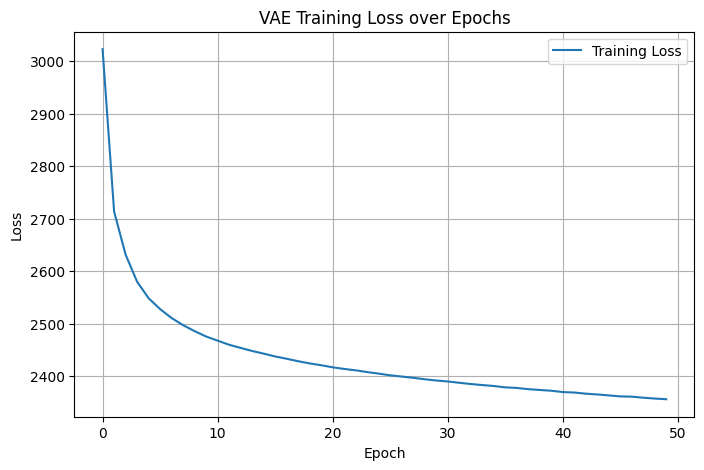

In [ ]:
import pickle
import matplotlib.pyplot as plt

# ✅ Load the saved loss values from the pickle file
with open("/content/gdrive/MyDrive/vae/vae_train_loss.pkl", "rb") as f:
    train_loss_avg = pickle.load(f)

# ✅ Plot the training loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(train_loss_avg, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


Validation & Evluation on Test Data
-------------------------

In [ ]:
import torch

# Load model weights
vae.load_state_dict(torch.load("/content/gdrive/MyDrive/vae/vae_best_weights.pth", map_location=device))
vae.eval()  # Set model to evaluation mode

# Evaluate on test data
test_loss_avg = 0
num_batches = 0

for image_batch, _ in test_dataloader:
    image_batch = image_batch.to(device)

    with torch.no_grad():
        # Forward pass through VAE
        image_batch_recon, latent_mu, latent_logvar = vae(image_batch)

        # Compute reconstruction + KL loss
        loss = vae_loss(image_batch_recon, image_batch, latent_mu, latent_logvar)

    test_loss_avg += loss.item()
    num_batches += 1

# Average loss across all batches
test_loss_avg /= num_batches
print('Average reconstruction error on test set: %f' % test_loss_avg)


Average reconstruction error on test set: 2386.403188


Visualize Reconstructions
--------------------------

Original images:


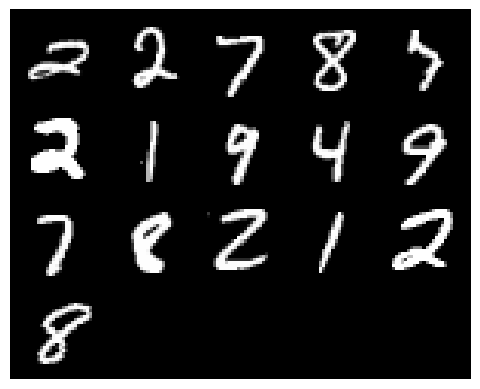

VAE reconstructed images:


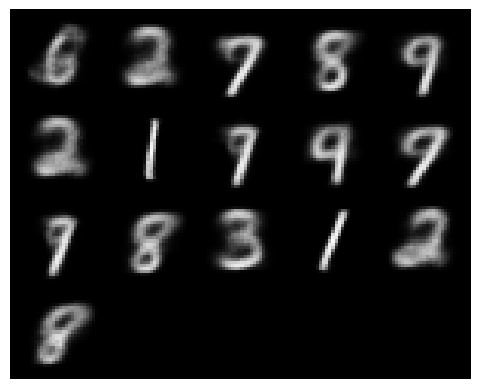

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import utils

# Put model in evaluation mode
vae.eval()

# Helper function to clamp values and prepare image
def to_img(x):
    x = x.clamp(0, 1)
    return x

# Show a single image (grid or individual)
def show_image(img):
    img = to_img(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')  # Hide axes for better visualization

# Function to visualize reconstructed images
def visualise_output(images, model):
    with torch.no_grad():
        images = images.to(device)
        reconstructed, _, _ = model(images)
        reconstructed = reconstructed.cpu()
        reconstructed = to_img(reconstructed)
        np_imagegrid = utils.make_grid(reconstructed[:25], nrow=5, padding=2).numpy()
        plt.imshow(np.transpose(np_imagegrid, (1, 2, 0)))
        plt.axis('off')
        plt.show()

# Get a batch of test images
images, labels = next(iter(test_dataloader))

# Show original images
print('Original images:')
show_image(utils.make_grid(images[:25], nrow=5, padding=2))
plt.show()

# Show VAE reconstructions
print('VAE reconstructed images:')
visualise_output(images, vae)


Interpolate in Latent Space
----------------------------

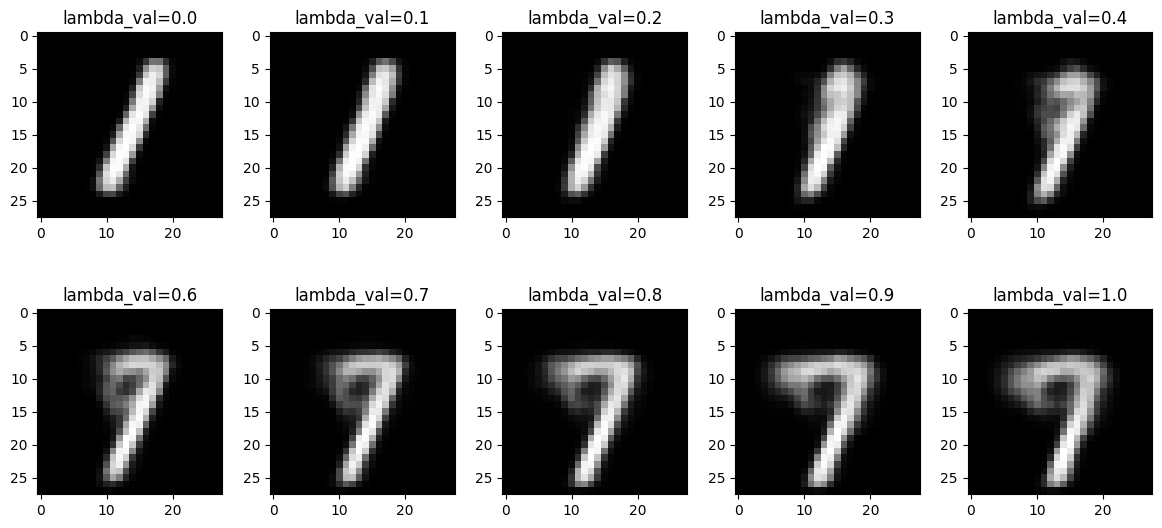

In [ ]:
vae.eval()

def interpolation(lambda1, model, img1, img2):

    with torch.no_grad():

        # latent vector of first image
        img1 = img1.to(device)
        latent_1, _ = model.encoder(img1)

        # latent vector of second image
        img2 = img2.to(device)
        latent_2, _ = model.encoder(img2)

        # interpolation of the two latent vectors
        inter_latent = lambda1* latent_1 + (1- lambda1) * latent_2

        # reconstruct interpolated image
        inter_image = model.decoder(inter_latent)
        inter_image = inter_image.cpu()

        return inter_image


digits = [[] for _ in range(10)]
for img_batch, label_batch in test_dataloader:
    for i in range(img_batch.size(0)):
        digits[label_batch[i]].append(img_batch[i:i+1])
    if sum(len(d) for d in digits) >= 1000:
        break;


lambda_range=np.linspace(0,1,10)

fig, axs = plt.subplots(2,5, figsize=(15, 6))
fig.subplots_adjust(hspace = .5, wspace=.001)
axs = axs.ravel()

for ind,l in enumerate(lambda_range):
    inter_image=interpolation(float(l), vae, digits[7][0], digits[1][0])

    inter_image = to_img(inter_image)

    image = inter_image.numpy()

    axs[ind].imshow(image[0,0,:,:], cmap='gray')
    axs[ind].set_title('lambda_val='+str(round(l,1)))
plt.show()

Sample Latent Vector from Prior (VAE as Generator)
-------------------------------------------------

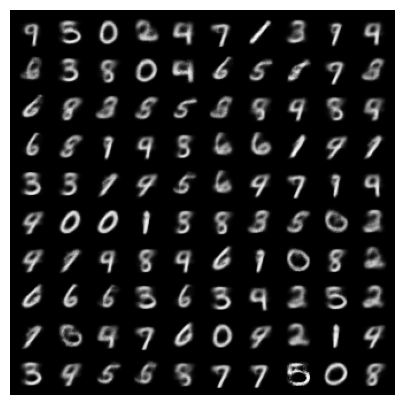

In [ ]:
vae.eval()

with torch.no_grad():

    # sample latent vectors from the normal distribution
    latent = torch.randn(128, latent_dims, device=device)

    # reconstruct images from the latent vectors
    img_recon = vae.decoder(latent)
    img_recon = img_recon.cpu()

    fig, ax = plt.subplots(figsize=(5, 5))
    show_image(torchvision.utils.make_grid(img_recon.data[:100],10,5))
    plt.show()

Show 2D Latent Space
---------------------

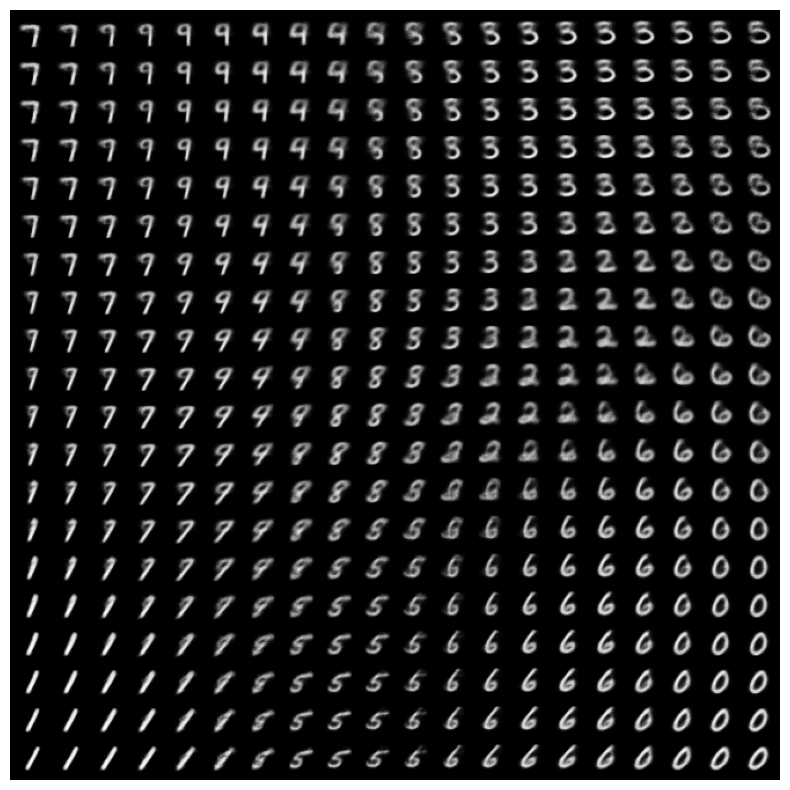

In [ ]:
# load a network that was trained with a 2d latent space
if latent_dims != 2:
    print('Please change the parameters to two latent dimensions.')

with torch.no_grad():

    # create a sample grid in 2d latent space
    latent_x = np.linspace(-1.5,1.5,20)
    latent_y = np.linspace(-1.5,1.5,20)
    latents = torch.FloatTensor(len(latent_y), len(latent_x), 2)
    for i, lx in enumerate(latent_x):
        for j, ly in enumerate(latent_y):
            latents[j, i, 0] = lx
            latents[j, i, 1] = ly
    latents = latents.view(-1, 2) # flatten grid into a batch

    # reconstruct images from the latent vectors
    latents = latents.to(device)
    image_recon = vae.decoder(latents)
    image_recon = image_recon.cpu()

    fig, ax = plt.subplots(figsize=(10, 10))
    show_image(torchvision.utils.make_grid(image_recon.data[:400],20,5))
    plt.show()

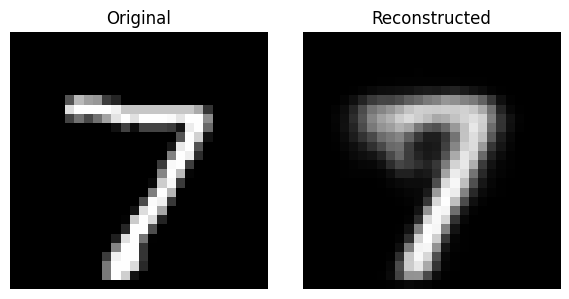

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

# Set model to evaluation mode
vae.eval()

# Load one image from the test dataset
single_image, label = test_dataset[0]  # Get the first image from the test dataset

# Unsqueeze to add batch dimension (1, 1, 28, 28)
input_image = single_image.unsqueeze(0).to(device)

# Forward pass through VAE
with torch.no_grad():
    reconstructed_image, _, _ = vae(input_image)

# Move to CPU and clamp values
original = single_image.cpu().squeeze().numpy()
reconstructed = reconstructed_image.cpu().squeeze().numpy()

# Plot original and reconstructed image side-by-side
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.tight_layout()
plt.show()


# Model Inference using Flask And Ngrok

In [ ]:
!curl -s https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null && echo "deb https://ngrok-agent.s3.amazonaws.com buster main" | sudo tee /etc/apt/sources.list.d/ngrok.list && sudo apt update && sudo apt install ngrok

deb https://ngrok-agent.s3.amazonaws.com buster main
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,806 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,103 kB]
Get:9 https://ngrok-agent.s3.amazonaws.com buster InRelease [20.3 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,759 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Package

how to get new authtoken?


Step 1: Go to the ngrok website by searching for "ngrok | Unified Application Delivery Platform for Developers" on Google.

Step 2: Sign up for ngrok using your email account and provide the necessary details.

Step 3: Navigate to the "Your Authtoken" section in your ngrok account settings, copy the token, and replace the existing token in the provided line of code (i.e., 24jMmkCh5Tr4hOZ9Dpg69QtTDSH_3n21SSxtBHr1F9QckcBzi).

In [ ]:
'''The first two commands install the pyngrok and flask-ngrok packages via pip, which are used for setting up secure tunnels to local servers for exposing them to the internet.
The third command sets the authentication token required for using ngrok, a service that creates secure tunnels from a public endpoint to a locally running web service,
facilitating testing and development of web applications.'''

!pip install pyngrok

!ngrok config add-authtoken 2GiH8URoZbuvn0eIqW4C8br8caN_73m7xUQYdwzsqxo9Jo6EX


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml



Note: The following code will run continuously until manually stopped by the user. If Ngrok generates a new URL, it is important to handle it carefully, especially if predictions are required each time.

index.html


Need to create a new folder as templates and then new to create a new file inside templates  and paste below set of html code

In [ ]:
# <!DOCTYPE html>
# <html lang="en">
# <head>
#     <meta charset="UTF-8">
#     <title>VAE Image Denoising</title>
#     <style>
#         body {
#             font-family: 'Segoe UI', sans-serif;
#             background: #f0f4f8;
#             margin: 0;
#             padding: 0;
#             text-align: center;
#         }

#         h2 {
#             color: #333;
#             margin-top: 30px;
#         }

#         form {
#             margin: 20px auto;
#             padding: 20px;
#             background: #ffffff;
#             border-radius: 10px;
#             box-shadow: 0 0 15px rgba(0, 0, 0, 0.1);
#             display: inline-block;
#         }

#         input[type="file"] {
#             padding: 10px;
#             margin: 10px;
#         }

#         button {
#             background-color: #007bff;
#             border: none;
#             color: white;
#             padding: 10px 20px;
#             text-transform: uppercase;
#             font-weight: bold;
#             cursor: pointer;
#             border-radius: 5px;
#         }

#         button:hover {
#             background-color: #0056b3;
#         }

#         .image-container {
#             display: flex;
#             justify-content: center;
#             gap: 40px;
#             margin-top: 40px;
#         }

#         .image-box {
#             background: #fff;
#             border-radius: 10px;
#             padding: 15px;
#             box-shadow: 0 0 12px rgba(0, 0, 0, 0.1);
#             width: 200px;
#         }

#         .image-box img {
#             width: 100%;
#             border-radius: 8px;
#             border: 2px solid #ddd;
#         }

#         .image-box h3 {
#             margin-top: 10px;
#             font-size: 16px;
#             color: #444;
#         }

#         footer {
#             margin-top: 60px;
#             font-size: 12px;
#             color: #888;
#         }
#     </style>
# </head>
# <body>

#     <h2>🧹 Variational Autoencoder: Image Denoising Demo</h2>

#     <form action="/process" method="post" enctype="multipart/form-data">
#         <input type="file" name="image" accept="image/*" required>
#         <button type="submit">Denoise</button>
#     </form>

#     {% if input_image %}
#     <div class="image-container">
#         <div class="image-box">
#             <img src="{{ input_image }}" alt="Original Image">
#             <h3>Original Image</h3>
#         </div>
#         <div class="image-box">
#             <img src="{{ output_image }}" alt="Denoised Image">
#             <h3>Denoised Output</h3>
#         </div>
#     </div>
#     {% endif %}

#     <footer>
#         © 2025 VAE Denoising Demo | Powered by Flask + PyTorch + Ngrok
#     </footer>

# </body>
# </html>


In [ ]:
import os
import torch
import torchvision.transforms as transforms
from flask import Flask, request, render_template
from werkzeug.utils import secure_filename
from pyngrok import ngrok
from PIL import Image

app = Flask(__name__)
UPLOAD_FOLDER = "static/uploads"
PROCESSED_FOLDER = "static/processed"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(PROCESSED_FOLDER, exist_ok=True)

# Load trained VAE model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device)
vae.eval()

# Preprocessing and transformation
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

# Ngrok
port = 5000
public_url = ngrok.connect(port).public_url
print(f"Running on: {public_url}")

@app.route("/")
def index():
    return render_template("index.html")

@app.route("/process", methods=["POST"])
def process_image():
    if "image" not in request.files:
        return "No file uploaded", 400

    file = request.files["image"]
    if file.filename == "":
        return "Empty filename", 400

    filename = secure_filename(file.filename)
    file_path = os.path.join(UPLOAD_FOLDER, filename)
    file.save(file_path)

    # Process image
    image = Image.open(file_path).convert("L")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output, _, _ = vae(image_tensor)
        output_image = output.squeeze().cpu().numpy()

    # Save denoised image
    output_path = os.path.join(PROCESSED_FOLDER, filename)
    plt.imsave(output_path, output_image, cmap="gray")

    return render_template("index.html",
                           input_image=file_path,
                           output_image=output_path)

if __name__ == '__main__':
    app.run()


Running on: https://1d1204b0cbc7.ngrok-free.app
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [15/Jul/2025 11:42:00] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jul/2025 11:42:00] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [15/Jul/2025 11:42:16] "POST /process HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jul/2025 11:42:17] "GET /static/uploads/mnist-image.png HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [15/Jul/2025 11:42:17] "GET /static/processed/mnist-image.png HTTP/1.1" 200 -
